# Лабораторная работа 12 — Ансамбли: бустинг

**Цель работы:** изучить методы бустинга (AdaBoost, Gradient Boosting, HistGradientBoosting), сравнить их качество на датасете GTZAN.

## Теоретическое введение

### Бустинг

**Бустинг** — метод построения ансамбля, при котором модели обучаются **последовательно**, и каждая следующая модель пытается исправить ошибки предыдущих. В отличие от бэггинга (параллельное обучение), бустинг целенаправленно фокусируется на «трудных» примерах.

### AdaBoost (Adaptive Boosting)

AdaBoost назначает каждому обучающему примеру вес. После обучения очередной слабой модели, веса неправильно классифицированных примеров увеличиваются, а правильных — уменьшаются. Следующая модель фокусируется на ошибках предыдущей. Итоговое предсказание — взвешенное голосование всех моделей.

### Градиентный бустинг (Gradient Boosting)

Градиентный бустинг обобщает идею бустинга: каждая следующая модель обучается предсказывать **остатки** (ошибки) предыдущего ансамбля. Формально это эквивалентно градиентному спуску в функциональном пространстве:

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

где $h_m$ — слабая модель, обученная на антиградиенте функции потерь, $\eta$ — **learning rate** (шаг обучения). Маленький learning rate замедляет обучение, но улучшает обобщение.

### HistGradientBoosting

`HistGradientBoostingClassifier` — быстрая реализация градиентного бустинга в scikit-learn, вдохновлённая LightGBM. Вместо точных порогов использует **гистограммные** приближения, что существенно ускоряет обучение на больших данных.

## 1. Загрузка и предобработка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.ensemble import (
    AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    roc_curve, auc
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

df = pd.read_csv('../datasets/gtzan/features_30_sec.csv')
X = df.drop(columns=['filename', 'label', 'length'])
y = df['label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
feature_names = X.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f'Датасет: {X.shape[0]} сэмплов, {X.shape[1]} признаков, {len(le.classes_)} классов')
print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')

Датасет: 1000 сэмплов, 57 признаков, 10 классов
Train: 800, Test: 200


## 2. Обучение бустинг-моделей

Обучим три метода бустинга и сравним их accuracy.

In [2]:
models = {
    'AdaBoost': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3),
        n_estimators=100, learning_rate=0.1, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42),
    'HistGradientBoosting': HistGradientBoostingClassifier(
        max_iter=200, max_depth=5, learning_rate=0.1, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f'{name}: accuracy = {acc:.4f}')

AdaBoost: accuracy = 0.6550


GradientBoosting: accuracy = 0.6950


HistGradientBoosting: accuracy = 0.7250


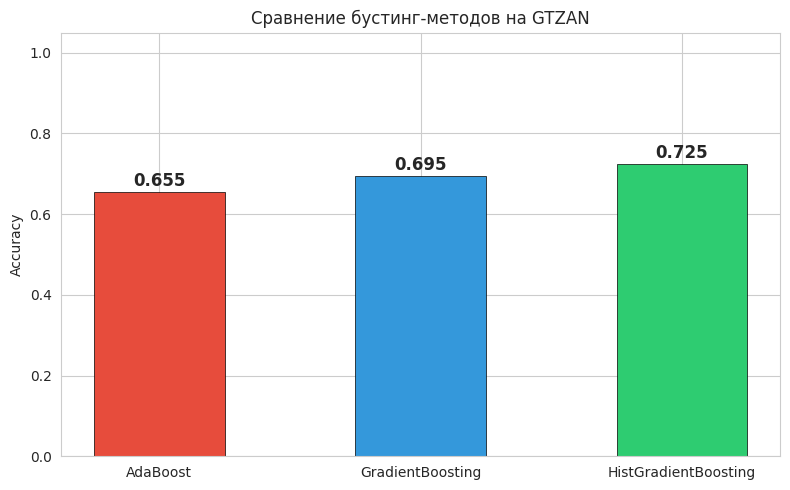

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
names = list(results.keys())
accs = list(results.values())
colors = ['#e74c3c', '#3498db', '#2ecc71']

bars = ax.bar(names, accs, color=colors, edgecolor='black', linewidth=0.5, width=0.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_ylabel('Accuracy')
ax.set_title('Сравнение бустинг-методов на GTZAN')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 3. Confusion matrix лучшей модели

Подробная оценка лучшего бустинг-метода.

=== HistGradientBoosting ===
              precision    recall  f1-score   support

       blues       0.71      0.85      0.77        20
   classical       0.86      0.95      0.90        20
     country       0.68      0.75      0.71        20
       disco       0.56      0.45      0.50        20
      hiphop       0.56      0.75      0.64        20
        jazz       0.78      0.90      0.84        20
       metal       1.00      0.85      0.92        20
         pop       0.84      0.80      0.82        20
      reggae       0.73      0.55      0.63        20
        rock       0.53      0.40      0.46        20

    accuracy                           0.72       200
   macro avg       0.73      0.72      0.72       200
weighted avg       0.73      0.72      0.72       200



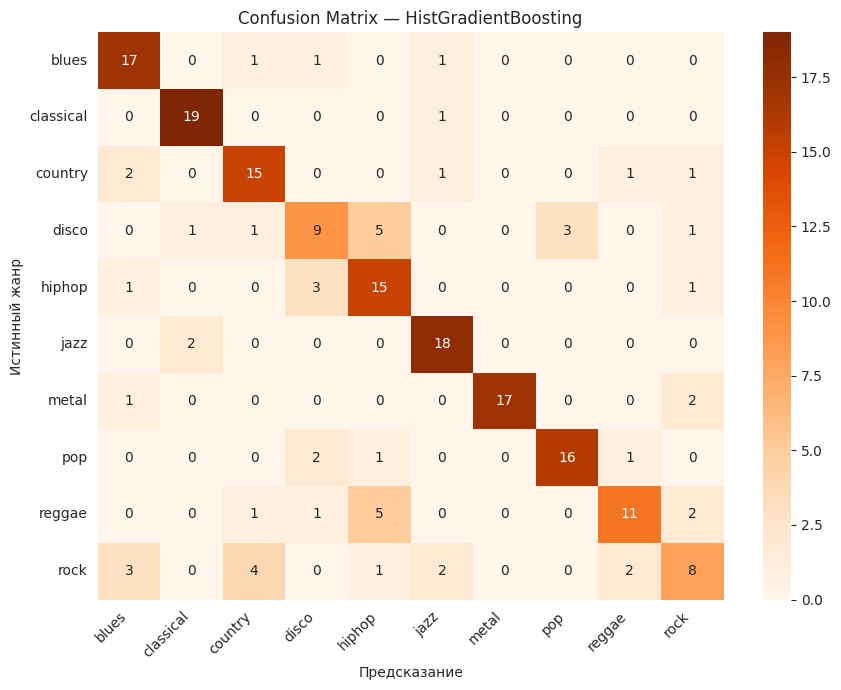

In [4]:
best_name = max(results, key=results.get)
best_model = models[best_name]
y_pred_best = best_model.predict(X_test)

print(f'=== {best_name} ===')
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax.set_xlabel('Предсказание')
ax.set_ylabel('Истинный жанр')
ax.set_title(f'Confusion Matrix — {best_name}')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. ROC-кривые — сравнение бустинг-методов

Построим micro-average ROC-кривые для каждого метода бустинга.

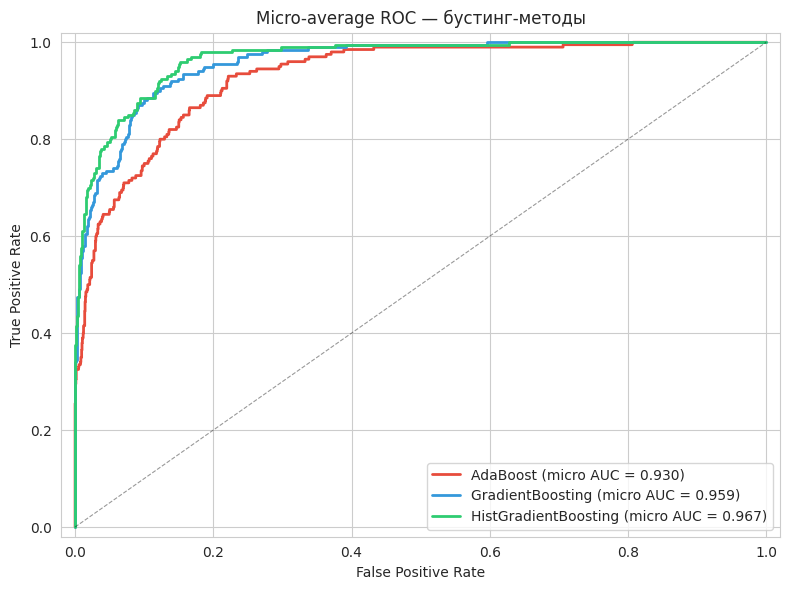

In [5]:
n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

fig, ax = plt.subplots(figsize=(8, 6))

for (name, model), color in zip(models.items(), colors):
    y_proba = model.predict_proba(X_test)
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
    auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (micro AUC = {auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Micro-average ROC — бустинг-методы')
ax.legend(loc='lower right')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
plt.tight_layout()
plt.show()

## 5. Влияние learning_rate

**Learning rate** (шаг обучения) — ключевой гиперпараметр бустинга. Маленький lr требует больше итераций, но обычно лучше обобщает.

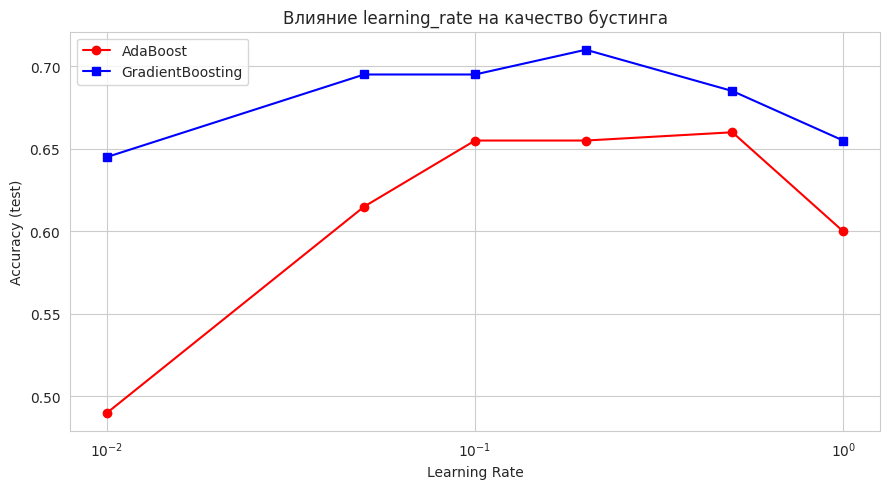

In [6]:
lr_values = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
lr_results = {'AdaBoost': [], 'GradientBoosting': []}

for lr in lr_values:
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3),
        n_estimators=100, learning_rate=lr, random_state=42)
    ada.fit(X_train, y_train)
    lr_results['AdaBoost'].append(accuracy_score(y_test, ada.predict(X_test)))
    
    gb = GradientBoostingClassifier(
        n_estimators=200, max_depth=3, learning_rate=lr, random_state=42)
    gb.fit(X_train, y_train)
    lr_results['GradientBoosting'].append(accuracy_score(y_test, gb.predict(X_test)))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(lr_values, lr_results['AdaBoost'], 'r-o', markersize=6, label='AdaBoost')
ax.plot(lr_values, lr_results['GradientBoosting'], 'b-s', markersize=6, label='GradientBoosting')
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Accuracy (test)')
ax.set_title('Влияние learning_rate на качество бустинга')
ax.set_xscale('log')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Важность признаков

Градиентный бустинг, как и случайный лес, позволяет оценить важность признаков.

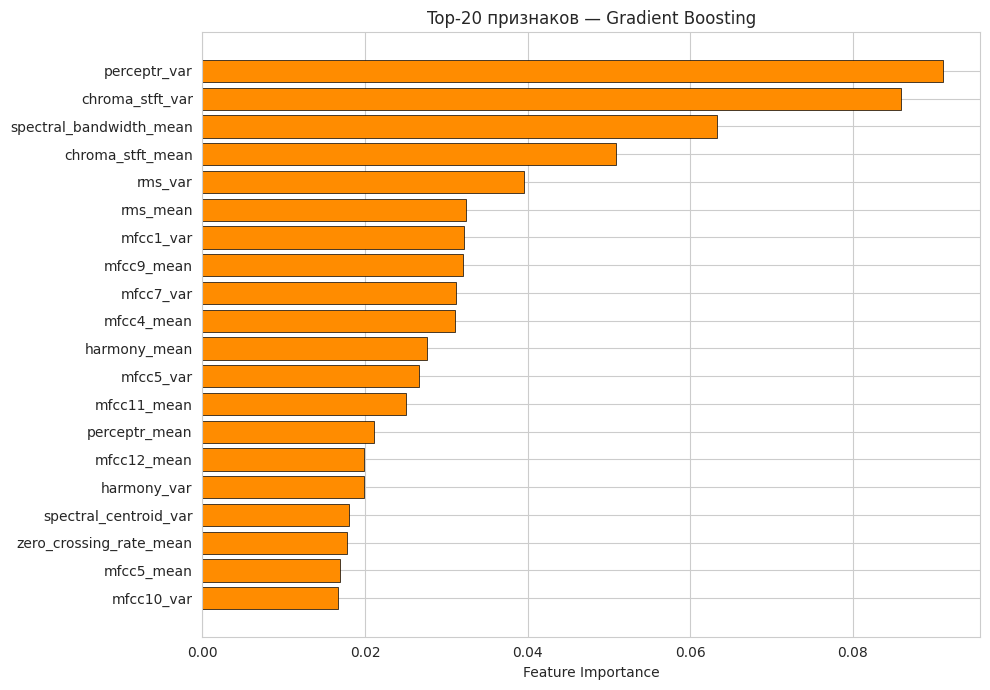

In [7]:
gb_model = models['GradientBoosting']
importances = gb_model.feature_importances_
imp_df = pd.DataFrame({'Признак': feature_names, 'Важность': importances})
imp_df = imp_df.sort_values('Важность', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(imp_df['Признак'], imp_df['Важность'], color='darkorange',
        edgecolor='black', linewidth=0.5)
ax.set_xlabel('Feature Importance')
ax.set_title('Top-20 признаков — Gradient Boosting')
plt.tight_layout()
plt.show()

## 7. Кросс-валидация — сравнение

Стратифицированная 5-fold кросс-валидация для объективного сравнения.

AdaBoost       : 0.6230 ± 0.0333


GradBoosting   : 0.7130 ± 0.0248


HistGradBoost  : 0.7440 ± 0.0385


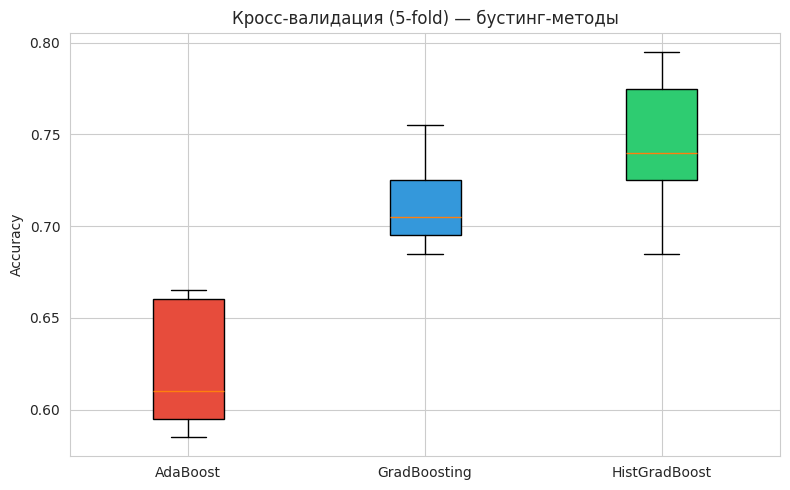

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'AdaBoost': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3),
        n_estimators=100, learning_rate=0.1, random_state=42),
    'GradBoosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42),
    'HistGradBoost': HistGradientBoostingClassifier(
        max_iter=200, max_depth=5, learning_rate=0.1, random_state=42),
}

cv_results = {}
for name, model in cv_models.items():
    scores = cross_val_score(model, X_scaled, y_encoded, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name:15s}: {scores.mean():.4f} ± {scores.std():.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot([cv_results[n] for n in cv_results],
                labels=list(cv_results.keys()), patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_ylabel('Accuracy')
ax.set_title('Кросс-валидация (5-fold) — бустинг-методы')
plt.tight_layout()
plt.show()

## Выводы

1. **Бустинг** (особенно градиентный) показывает высокое качество классификации жанров GTZAN, превосходя отдельные деревья и бэггинг из предыдущей лабораторной.

2. **GradientBoosting** и **HistGradientBoosting** превосходят **AdaBoost** на мультиклассовой задаче, поскольку градиентный бустинг более гибко оптимизирует функцию потерь.

3. **Learning rate** критически важен: слишком большой lr ведёт к переобучению, слишком маленький — к недообучению при фиксированном числе итераций. Оптимальный lr ≈ 0.1.

4. **HistGradientBoosting** — быстрая альтернатива XGBoost/LightGBM внутри scikit-learn, показывающая сопоставимое качество.

5. **Feature importance** из градиентного бустинга подтверждает, что MFCC-коэффициенты и спектральные характеристики — ключевые признаки для классификации жанров.

6. Бустинг — мощный метод, но требует тщательной настройки гиперпараметров (lr, n_estimators, max_depth) для достижения лучших результатов.